In [12]:
# Cell 1: Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the datasets
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

print(f"Red wine dataset shape: {red_wine.shape}")
print(f"White wine dataset shape: {white_wine.shape}")

Red wine dataset shape: (1599, 12)
White wine dataset shape: (4898, 12)


In [13]:
# Cell 2: Data Profiling
print("--- Red Wine Info ---")
red_wine.info()

print("\n--- White Wine Info ---")
white_wine.info()

print("\nMissing values in Red Wine:\n", red_wine.isnull().sum().sum())
print("Missing values in White Wine:\n", white_wine.isnull().sum().sum())

--- Red Wine Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

--- White Wine Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data 

In [14]:
# Cell 3: Combine Datasets
red_wine['type'] = 'red'
white_wine['type'] = 'white'

# Concatenate into one master dataframe
df = pd.concat([red_wine, white_wine], ignore_index=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [15]:
# Cell 4: Comparative Aggregations
df.groupby('type').mean().T

type,red,white
fixed acidity,8.319637,6.854788
volatile acidity,0.527821,0.278241
citric acid,0.270976,0.334192
residual sugar,2.538806,6.391415
chlorides,0.087467,0.045772
free sulfur dioxide,15.874922,35.308085
total sulfur dioxide,46.467792,138.360657
density,0.996747,0.994027
pH,3.311113,3.188267
sulphates,0.658149,0.489847


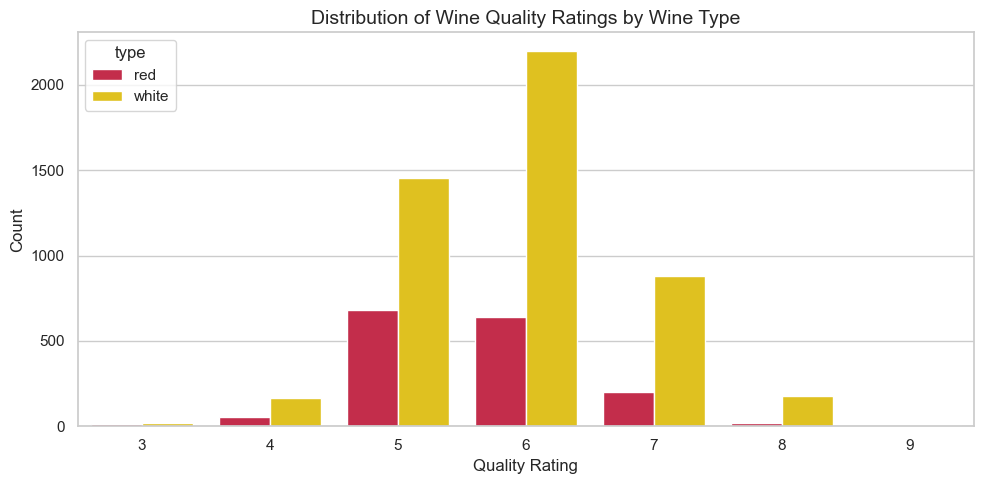

In [21]:
# Cell 5: Quality Count Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='quality', hue='type', palette=['crimson', 'gold'], ax=ax)
ax.set_title("Distribution of Wine Quality Ratings by Wine Type", fontsize=14)
ax.set_xlabel("Quality Rating", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

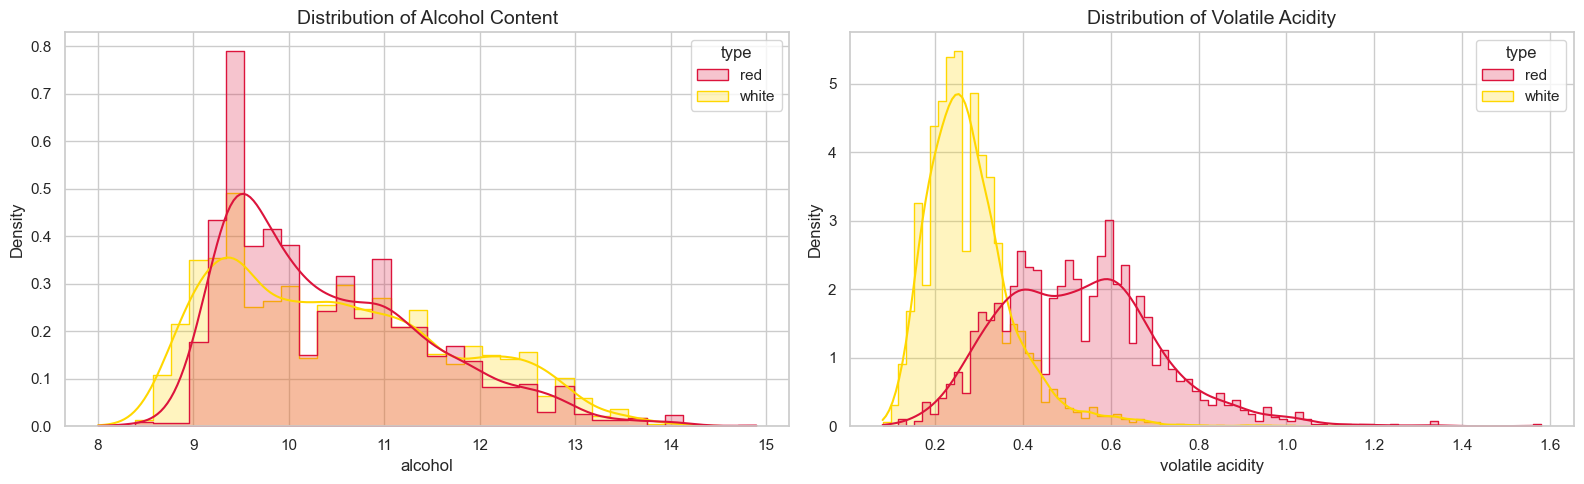

In [22]:
# Cell 6: Distribution of key metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Alcohol Distribution
sns.histplot(data=df, x='alcohol', hue='type', kde=True, element='step', stat='density', common_norm=False, palette=['crimson', 'gold'], ax=axes[0])
axes[0].set_title("Distribution of Alcohol Content", fontsize=14)

# Volatile Acidity Distribution
sns.histplot(data=df, x='volatile acidity', hue='type', kde=True, element='step', stat='density', common_norm=False, palette=['crimson', 'gold'], ax=axes[1])
axes[1].set_title("Distribution of Volatile Acidity", fontsize=14)

plt.tight_layout()
plt.show()

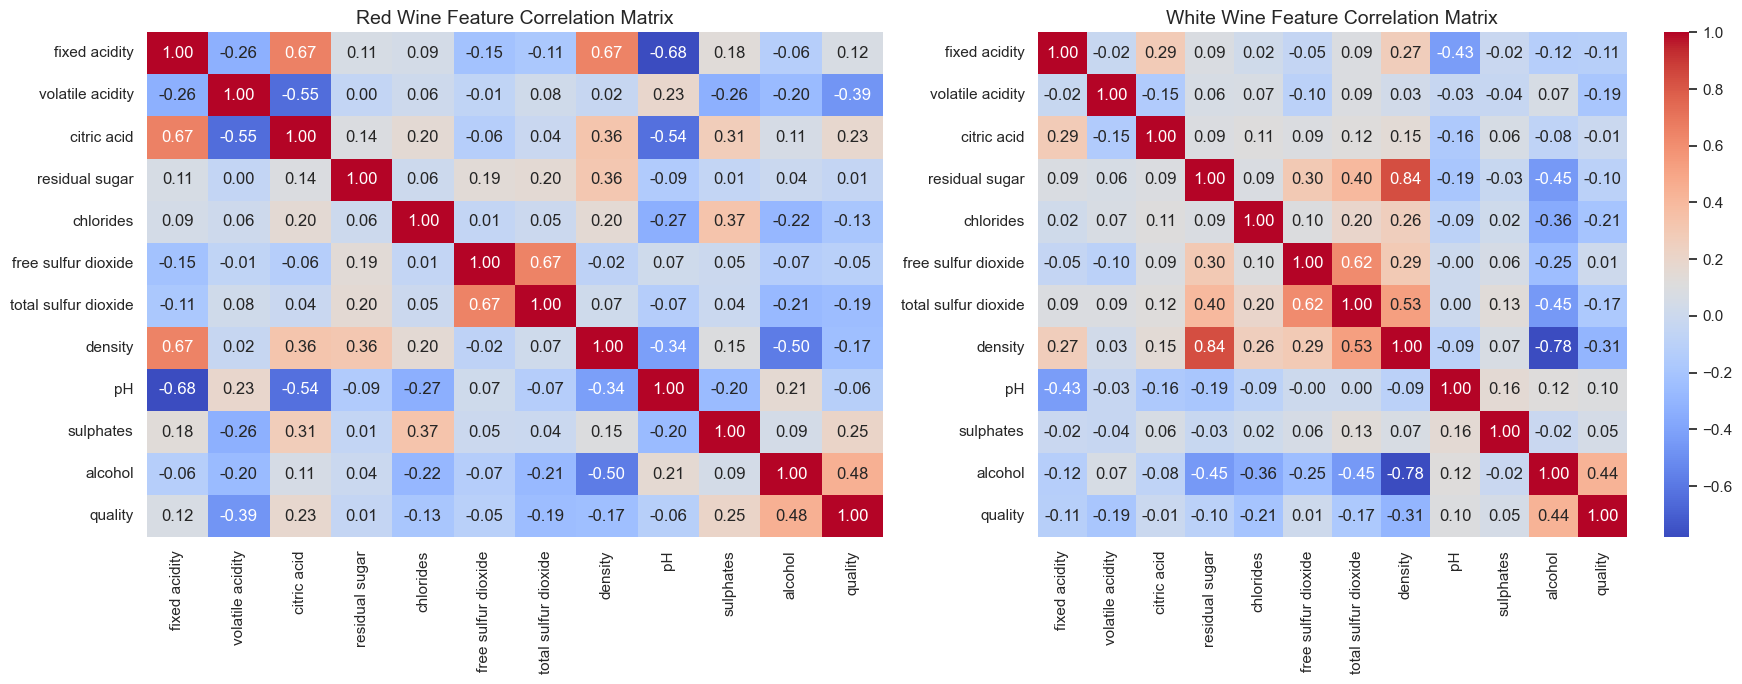

In [26]:
# Cell 7: Dual Heatmaps for Correlation Matrix (Fixed Version)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Red Wine Matrix - filter for numeric columns first
red_numeric = red_wine.select_dtypes(include=['number'])
sns.heatmap(red_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False, ax=axes[0])
axes[0].set_title("Red Wine Feature Correlation Matrix", fontsize=14)

# White Wine Matrix - filter for numeric columns first
white_numeric = white_wine.select_dtypes(include=['number'])
sns.heatmap(white_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("White Wine Feature Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

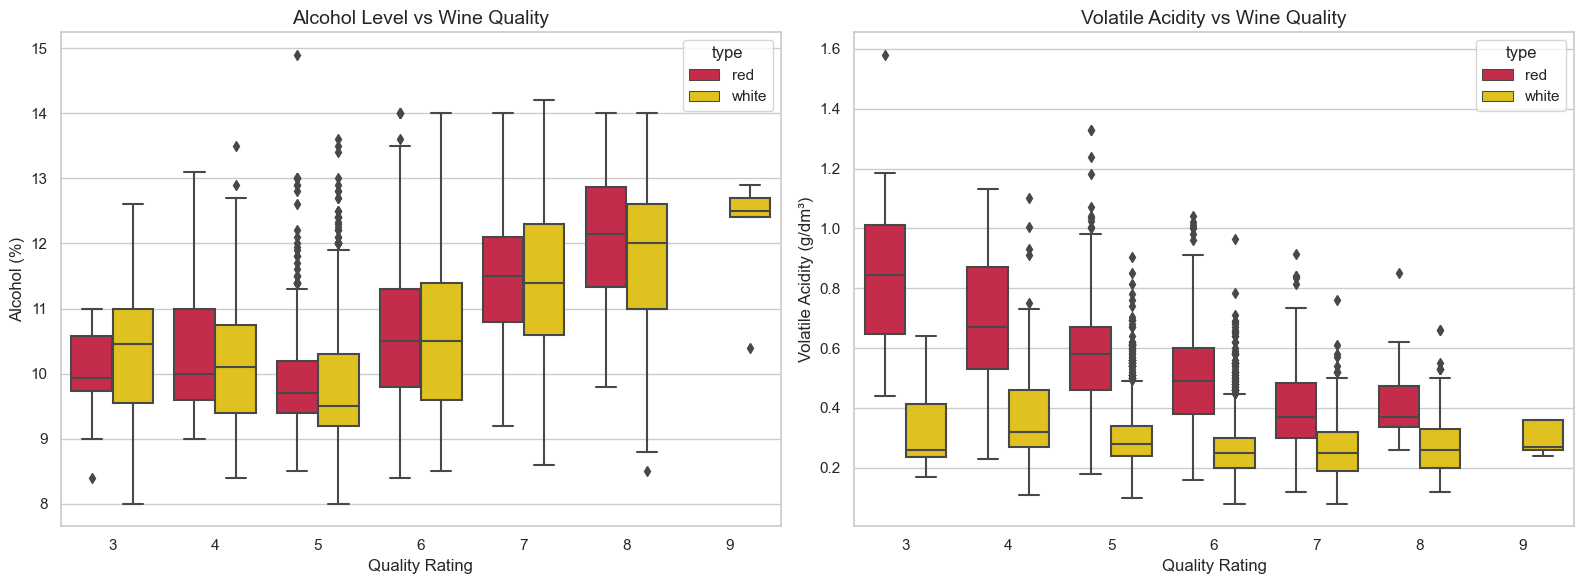

In [23]:
# Cell 8: Box plots against quality
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Alcohol vs Quality
sns.boxplot(data=df, x='quality', y='alcohol', hue='type', palette=['crimson', 'gold'], ax=axes[0])
axes[0].set_title("Alcohol Level vs Wine Quality", fontsize=14)
axes[0].set_xlabel("Quality Rating")
axes[0].set_ylabel("Alcohol (%)")

# Volatile Acidity vs Quality
sns.boxplot(data=df, x='quality', y='volatile acidity', hue='type', palette=['crimson', 'gold'], ax=axes[1])
axes[1].set_title("Volatile Acidity vs Wine Quality", fontsize=14)
axes[1].set_xlabel("Quality Rating")
axes[1].set_ylabel("Volatile Acidity (g/dm³)")

plt.tight_layout()
plt.show()